# 🌬️🌧️🔥 Land Surface Model Variables Analysis
## Step 4: Climatic Variables + Land Cover — Biswas et al.-Aligned Feature Set — India (2000–2022)

**Extends:** FLDAS_NOAH01_C_GL_M.001 (Noah Land Surface Model, MERRA-2 + CHIRPS forced), monthly, 0.1°,
plus the ESA CCI/C3S LCCS land-cover archive already used by Step 5.
**Data:** `FLDAS_NOAH01_C_GL_M.A<YYYYMM>.001.nc`, one file per month, already downloaded into this folder
**Study period:** 1 Nov 2000 – 15 Dec 2022 — **matches Step 1 (fire), Step 2 (NDVI), Step 3 (LST) and Step 5 (integration) exactly**

---
### Biswas et al. variable coverage

This notebook targets the full baseline variable set (NDVI and LST Day/Night are covered by
Steps 2–3, not repeated here) so results are directly comparable to that study:

| # | Biswas et al. variable | Source | Status |
|---|--------|------------------|-------|
| 1 | Air Temperature (K) | `Tair_f_tavg` | New in this notebook |
| 2 | Wind Speed (m/s) | `Wind_f_tavg` | Carried over |
| 3 | Specific Humidity (kg/kg) | `Qair_f_tavg` | New (previously internal-only, used for RH) |
| 4 | Precipitation (mm/h) | `Rainf_f_tavg` × 3600 | New unit (previously mm/month only, kept alongside) |
| 5 | Soil Moisture (kg/m²) | `SoilMoi*_tavg` (4 depth layers, m³/m³ × depth × 1000) | New — surface (0-10cm) as the headline layer, full 0-200cm profile as a bonus |
| 6 | Net LW Radiation (W/m²) | `Lwnet_tavg` | New |
| 7 | Fire Points (CSV) | Step 1 archive | Carried over (fire coincidence check) |
| 8 | Land Cover (22 classes) | ESA CCI/C3S LCCS, reclassified to the 22 base LCCS parent codes | New — Step 11 below |
| 9 | Burned Area | — | **Not available in this project** (no MODIS MCD64A1/FireCCI/GABAM archive present) — fire points remain the only fire-occurrence signal |
| — | Relative Humidity (%) | Derived (Clausius-Clapeyron) | Bonus, not in Biswas et al. but kept since it's a byproduct of #1/#3 |

### What this step delivers

| # | Metric | Notes |
|---|--------|-------|
| 1–6 | Climatology, anomaly, Mann-Kendall trend (monthly) + significance (p-value) | Same treatment as wind/precip/RH for every new variable |
| 7 | Fire coincidence | Are fire-affected pixel-months drier / windier / lower-humidity / lower-soil-moisture? |
| 8 | NDVI-grid reprojection | `rasterio.warp.reproject`, **bilinear** (FLDAS 0.1° → NDVI grid 0.01° is upsampling, unlike Step 3/Step 5's finer→coarser averaging) |
| 9 | Land cover 22-class fractions | Per-pixel fractional cover of each of the 22 base ESA CCI LCCS classes, area-averaged onto the NDVI grid |

### Design notes (where this differs from Step 3's LST pipeline)

- FLDAS is **natively monthly** (one file = one month already), unlike MODIS LST's 8-day
  composites — so there's no need for a streaming multi-observation-per-month aggregation
  step. Each monthly file is read, cropped to an India bounding box, and stacked directly.
- FLDAS is **global** at 0.1° with `Y` ascending (south→north); it's cropped to an India
  bounding box and flipped to north-up (row 0 = north) so its affine transform follows the
  same raster convention as every other layer in this project.
- **GPU-accelerated where it matters:** same as Step 3 -- CuPy runs a row-tiled
  (memory-bounded) Mann-Kendall trend test on the monthly arrays, with auto-fallback to
  CPU (NumPy) if no CUDA device is found. The trend test also computes a two-sided
  normal-approximation p-value (same erf-based formula as Step 2/NDVI and Step 3/LST),
  so trend significance is reported consistently across all three steps.

---



## 📦 Step 0 — Install Required Libraries

Run once. `cupy-cuda12x` + the NVIDIA JIT-header packages enable GPU acceleration.
If CuPy fails to install/import, the pipeline automatically falls back to CPU (NumPy) --
still correct, just slower.

In [1]:
import subprocess, sys

packages = [
    "numpy", "pandas", "matplotlib", "geopandas", "tqdm",
    "rasterio", "pyogrio", "xarray", "netCDF4",
    # GPU acceleration (native Windows -- no WSL required)
    "cupy-cuda12x",
    "nvidia-cuda-runtime-cu12",
    "nvidia-cuda-nvrtc-cu12",
    "nvidia-cuda-nvcc-cu12",
]

for pkg in packages:
    try:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])
    except subprocess.CalledProcessError as e:
        print(f"WARNING: failed to install {pkg} ({e}) -- continuing")

print("Library installation complete.")


Library installation complete.


## 📚 Step 1 — Imports & GPU Detection

Same auto-detect / auto-fallback pattern as Step 3 (LST).

In [2]:
import os
import re
import time
import gc
import io
import contextlib
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import rasterio
from rasterio.features import rasterize
from rasterio.warp import reproject, Resampling
import xarray as xr
import netCDF4 as nc_lib
from pathlib import Path
from tqdm import tqdm
from scipy.special import erf as erf_cpu

warnings.filterwarnings("ignore")

# GPU detection (CuPy) -- falls back cleanly to NumPy if unavailable
GPU_AVAILABLE = False
gpu_name = "N/A"
erf_gpu = None
try:
    # Suppress CuPy's one-time optional-integration warm-up noise (see Step 3's LST
    # notebook for the same pattern) -- real GPU failures still raise normally below.
    from IPython.core.interactiveshell import InteractiveShell
    _orig_showtraceback = InteractiveShell.showtraceback
    InteractiveShell.showtraceback = lambda *a, **k: None
    try:
        with contextlib.redirect_stderr(io.StringIO()):
            import cupy as cp
            from cupyx.scipy.special import erf as erf_gpu
            _test = cp.array([1, 2, 3]) * 2      # forces JIT compile now, not mid-pipeline
            _ = cp.isin(_test, cp.array([2]))
    finally:
        InteractiveShell.showtraceback = _orig_showtraceback
    GPU_AVAILABLE = True
    gpu_name = cp.cuda.runtime.getDeviceProperties(0)['name'].decode()
    free_mem, total_mem = cp.cuda.Device(0).mem_info
    print("GPU acceleration ON")
    print(f"   Device : {gpu_name}")
    print(f"   VRAM   : {free_mem/1e9:.1f} GB free / {total_mem/1e9:.1f} GB total")
except Exception as e:
    import numpy as cp   # alias so downstream code (cp.xxx) works unchanged on CPU
    erf_gpu = None
    print(f"GPU unavailable ({e})")
    print("   Falling back to CPU (NumPy). Pipeline will still run correctly, just slower.")

def to_host(arr):
    # Bring a cp array back to a plain NumPy array (no-op on CPU fallback)
    return cp.asnumpy(arr) if GPU_AVAILABLE else arr

def erf_fn(x):
    # Same GPU/CPU erf dispatch Step 2 (NDVI) uses for its Mann-Kendall p-value
    return erf_gpu(x) if GPU_AVAILABLE else erf_cpu(x)

print("\nAll libraries imported successfully!")


GPU acceleration ON
   Device : NVIDIA RTX PRO 4500 Blackwell
   VRAM   : 32.8 GB free / 34.2 GB total

All libraries imported successfully!


## ⚙️ Step 2 — Configuration
> Edit only this cell if your file names/paths differ.

In [3]:
# ═══════════════════════════════════════════════════
#  CONFIGURE PATHS
# ═══════════════════════════════════════════════════
BASE_DIR = r"D:\FOREST FIRE MAPPING(INDIA)"
FLDAS_DIR = os.path.join(
    BASE_DIR,
    "FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)",
)
LST_ANALYSIS_DIR = os.path.join(BASE_DIR, "LST_analysis")

# Step 1 -- fire points (for the fire-coincidence check)
FIRE_CSV_PATH = os.path.join(BASE_DIR, "Forest fire Extraction in INDIA(2000-2022)",
                              "Forest_Fire_Outputs", "all_forest_fires_2000_2022.csv")

# Same India boundary as Step 1 / Step 3 / Step 4 (dissolved State boundary, EPSG:3857 fix)
BOUNDARY_SHP = os.path.join(LST_ANALYSIS_DIR, "India_State_Boundary.shp")

# NDVI pipeline's own grid -- the reference grid every other source is aligned onto
NDVI_RAW_DIR = os.path.join(BASE_DIR, "NDVI_DATA_INDIA_", "NDVI TIF File_INDIA")

# Step 4's own LULC archive (ESA CCI/C3S LCCS, 300m) -- reused here for the 22-class breakdown
LULC_DIR = os.path.join(BASE_DIR, "Forest fire Extraction in INDIA(2000-2022)",
                         "Forest_Fire_Outputs", "lulc_extracted")
LULC_YEAR = 2020  # matches Step 4's LULC_RECENT_YEAR convention

OUTPUT_DIR = os.path.join(FLDAS_DIR, "FLDAS_Outputs")
NDVI_ALIGNED_DIR = os.path.join(OUTPUT_DIR, "NDVI_Aligned_GeoTIFFs")
os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(NDVI_ALIGNED_DIR, exist_ok=True)

# Study period -- matches Steps 1-4 exactly
STUDY_START_DATE = pd.Timestamp("2000-11-01")
STUDY_END_DATE = pd.Timestamp("2022-12-15")
CLIMATOLOGY_START = pd.Timestamp("2001-01-01")
CLIMATOLOGY_END = pd.Timestamp("2020-12-31")

# India bounding box (with buffer) -- cheap pre-crop of the global FLDAS grid before
# exact polygon masking
LON_MIN, LON_MAX = 67.0, 98.5
LAT_MIN, LAT_MAX = 5.0, 38.5

print("Configuration loaded:")
print(f"   FLDAS_DIR    : {FLDAS_DIR}  (exists: {os.path.isdir(FLDAS_DIR)})")
print(f"   Fire archive : {FIRE_CSV_PATH}  (exists: {os.path.exists(FIRE_CSV_PATH)})")
print(f"   Boundary     : {BOUNDARY_SHP}  (exists: {os.path.exists(BOUNDARY_SHP)})")
print(f"   NDVI grid ref: {NDVI_RAW_DIR}  (exists: {os.path.isdir(NDVI_RAW_DIR)})")
print(f"   LULC archive : {LULC_DIR}  (exists: {os.path.isdir(LULC_DIR)})")
print(f"   Outputs      : {OUTPUT_DIR}")
print(f"   Study period : {STUDY_START_DATE.date()} to {STUDY_END_DATE.date()}")
print(f"   Climatology  : {CLIMATOLOGY_START.date()} to {CLIMATOLOGY_END.date()}")


Configuration loaded:
   FLDAS_DIR    : D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)  (exists: True)
   Fire archive : D:\FOREST FIRE MAPPING(INDIA)\Forest fire Extraction in INDIA(2000-2022)\Forest_Fire_Outputs\all_forest_fires_2000_2022.csv  (exists: True)
   Boundary     : D:\FOREST FIRE MAPPING(INDIA)\LST_analysis\India_State_Boundary.shp  (exists: True)
   NDVI grid ref: D:\FOREST FIRE MAPPING(INDIA)\NDVI_DATA_INDIA_\NDVI TIF File_INDIA  (exists: True)
   LULC archive : D:\FOREST FIRE MAPPING(INDIA)\Forest fire Extraction in INDIA(2000-2022)\Forest_Fire_Outputs\lulc_extracted  (exists: True)
   Outputs      : D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs
   Study period : 2000-11-01 to 2022-12-15
   Climatology  : 2001-01-01 to 2020-12-31


## 📍 Step 3 — India Boundary

Same boundary and CRS fix as Step 1 / Step 3 (LST) / Step 5 (Integrated): this shapefile
ships without a `.prj`, but its raw coordinates are Web Mercator meters, not lon/lat.

In [4]:
print("Loading India boundary...")
india_boundary = gpd.read_file(BOUNDARY_SHP)
if india_boundary.crs is None:
    india_boundary = india_boundary.set_crs("EPSG:3857", allow_override=True)
india_boundary = india_boundary.to_crs("EPSG:4326")
india_geom = india_boundary.dissolve(by=None).geometry.iloc[0]
print(f"   Bounds: lon=[{india_geom.bounds[0]:.2f}, {india_geom.bounds[2]:.2f}], "
      f"lat=[{india_geom.bounds[1]:.2f}, {india_geom.bounds[3]:.2f}]")
print("\nIndia boundary ready")


Loading India boundary...


   Bounds: lon=[68.12, 97.41], lat=[6.75, 37.10]

India boundary ready


## 📂 Step 4 — Discover FLDAS Monthly Files

Scans `FLDAS_DIR` for `FLDAS_NOAH01_C_GL_M.A<YYYYMM>.001.nc`, parses the year/month from
the filename, and keeps files within the study period.

In [5]:
print("Scanning for FLDAS monthly files...")

date_re = re.compile(r"\.A(\d{4})(\d{2})\.001\.nc$")
fldas_files = []
for fp in Path(FLDAS_DIR).glob("FLDAS_NOAH01_C_GL_M.A??????.001.nc"):
    m = date_re.search(fp.name)
    if m:
        year, month = int(m.group(1)), int(m.group(2))
        fldas_files.append((year, month, fp))

df_index = pd.DataFrame(sorted(fldas_files), columns=["year", "month", "path"])
df_index["date"] = pd.to_datetime(dict(year=df_index.year, month=df_index.month, day=1))
print(f"   Files found: {len(df_index)}")

df_study = df_index[(df_index["date"] >= STUDY_START_DATE) & (df_index["date"] <= STUDY_END_DATE)].reset_index(drop=True)
print(f"   Within study period ({STUDY_START_DATE.date()} to {STUDY_END_DATE.date()}): {len(df_study)}")

if len(df_study) == 0:
    print("WARNING: No FLDAS files found in the study period!")
elif len(df_study) < 266:
    print(f"   NOTE: expected up to 266 months -- {266 - len(df_study)} still missing from the archive. "
          f"Run download_fldas_missing.py to fill the gap before trusting the trend/climatology results.")


Scanning for FLDAS monthly files...
   Files found: 266
   Within study period (2000-11-01 to 2022-12-15): 266


## 🔧 Step 5 — Read/Crop Pipeline

Helper functions to open one FLDAS monthly NetCDF via `xarray`, crop it to an India
bounding box (cheap -- avoids ever materializing the full global 1500×3600 grid), flip it
to north-up raster convention, mask the `-9999` fill value, and derive the full
Biswas-aligned variable set:

- **Wind speed** (m/s) — used as-is
- **Air temperature** (K) — `Tair_f_tavg`, used as-is
- **Specific humidity** (kg/kg) — `Qair_f_tavg`, used as-is
- **Precipitation** (mm/h and mm/month) — `Rainf_f_tavg` is a rate (kg m⁻² s⁻¹ ≡ mm/s water
  equivalent); ×3600 gives mm/h (Biswas et al.'s unit), ×seconds-in-month gives the monthly
  total (kept for the climatology/trend view)
- **Soil moisture** (kg/m²) — `SoilMoi<depth>_tavg` is volumetric (m³/m³) per Noah's 4 depth
  layers (0-10/10-40/40-100/100-200cm); converting to a mass-per-area (kg/m²) multiplies
  each layer's fraction by its thickness (m) and water density (1000 kg/m³) -- the surface
  (0-10cm) layer is used as the headline feature, the summed 0-200cm profile as a bonus
- **Net LW radiation** (W/m²) — `Lwnet_tavg`, used as-is
- **Relative humidity** (%) — derived from specific humidity, air temperature and surface
  pressure (`Psurf_f_tavg`) via the Clausius-Clapeyron saturation-vapor-pressure
  approximation (bonus, not in Biswas et al.)

In [6]:
# Noah LSM's 4 fixed soil-layer thicknesses (m), top to bottom
SOIL_LAYER_DEPTHS_M = [0.10, 0.30, 0.60, 1.00]
SOIL_LAYER_VARS = ["SoilMoi00_10cm_tavg", "SoilMoi10_40cm_tavg", "SoilMoi40_100cm_tavg", "SoilMoi100_200cm_tavg"]


def open_fldas_month(path):
    """Open one FLDAS monthly file, crop to India bbox, and flip to north-up."""
    ds = xr.open_dataset(path)
    sub = ds.sel(Y=slice(LAT_MIN, LAT_MAX), X=slice(LON_MIN, LON_MAX))
    sub = sub.isel(Y=slice(None, None, -1))  # Y is ascending (south->north) in FLDAS

    def get(varname):
        arr = sub[varname].values[0].astype(np.float32)
        return np.where(arr <= -9998.0, np.nan, arr)

    wind = get("Wind_f_tavg")          # m/s
    rainf = get("Rainf_f_tavg")        # kg m-2 s-1
    qair = get("Qair_f_tavg")          # kg/kg
    tair = get("Tair_f_tavg")          # K
    psurf = get("Psurf_f_tavg")        # Pa
    lwnet = get("Lwnet_tavg")          # W/m2
    soilmoi_layers = [get(v) for v in SOIL_LAYER_VARS]  # m3/m3, top to bottom

    lat = sub["Y"].values
    lon = sub["X"].values
    ds.close()
    return wind, rainf, qair, tair, psurf, lwnet, soilmoi_layers, lat, lon


def month_to_precip_mm(rainf, year, month):
    days = pd.Timestamp(year=year, month=month, day=1).days_in_month
    return rainf * days * 86400.0


def rainf_to_mm_per_hour(rainf):
    return rainf * 3600.0


def soil_moisture_kgm2(soilmoi_layers):
    """Volumetric fraction (m3/m3) x layer thickness (m) x water density (1000 kg/m3)."""
    layers_kgm2 = [frac * depth * 1000.0 for frac, depth in zip(soilmoi_layers, SOIL_LAYER_DEPTHS_M)]
    surface_kgm2 = layers_kgm2[0]                     # 0-10cm, the headline feature
    total_kgm2 = sum(layers_kgm2)                      # 0-200cm profile, bonus
    return surface_kgm2, total_kgm2


def compute_relative_humidity(qair, tair_k, psurf_pa):
    tc = tair_k - 273.15
    es_hpa = 6.112 * np.exp((17.67 * tc) / (tc + 243.5))
    p_hpa = psurf_pa / 100.0
    e_hpa = (qair * p_hpa) / (0.622 + 0.378 * qair)
    rh = 100.0 * e_hpa / es_hpa
    return np.clip(rh, 0.0, 100.0)


print("Read/crop pipeline ready")


Read/crop pipeline ready


## 📊 Step 6 — Stream All Months, Build Monthly Arrays + Climatology

Unlike Step 3 (LST), FLDAS is already monthly, so there's no multi-observation-per-month
aggregation to do -- each file is read, cropped, masked to India, and written directly
into a `(n_months, H, W)` array. Along the way this also accumulates the 2001-2020
per-calendar-month climatology sums (same baseline window as Step 3), so climatology and
monthly anomalies fall out of a single pass.

In [7]:
if len(df_study) == 0:
    print("Cannot proceed: no FLDAS data for study period.")
else:
    t0 = time.time()

    first_wind, _, _, _, _, _, _, lat0, lon0 = open_fldas_month(df_study.iloc[0]["path"])
    H, W = first_wind.shape
    res_lon = float(lon0[1] - lon0[0])
    res_lat = float(lat0[0] - lat0[1])
    west = float(lon0[0] - res_lon / 2)
    north = float(lat0[0] + res_lat / 2)
    transform_ref = rasterio.transform.from_origin(west, north, res_lon, res_lat)
    crs_ref = "EPSG:4326"
    print(f"FLDAS India-cropped grid: {H} x {W} px, res={res_lon:.3f} deg")

    india_mask = rasterize(
        [(india_geom, 1)], out_shape=(H, W), transform=transform_ref, fill=0, dtype=np.uint8
    ).astype(bool)
    n_inside = int(india_mask.sum())
    print(f"India boundary mask: {n_inside:,} / {H*W:,} px ({100*n_inside/(H*W):.1f}%)")

    n_months = len(df_study)
    VAR_NAMES = ["wind", "precip", "precip_mmh", "qair", "rh", "tair", "lwnet", "soilm_surf", "soilm_total"]
    monthly = {v: np.full((n_months, H, W), np.nan, dtype=np.float32) for v in VAR_NAMES}
    clim_sum = {v: np.zeros((12, H, W), dtype=np.float32) for v in VAR_NAMES}
    clim_cnt = {v: np.zeros((12, H, W), dtype=np.uint8) for v in VAR_NAMES}

    ym_index = {(row.year, row.month): i for i, row in df_study.iterrows()}
    national_ts = {v: [] for v in VAR_NAMES}

    for i, row in tqdm(df_study.iterrows(), total=n_months, desc="Streaming FLDAS months"):
        wind, rainf, qair, tair, psurf, lwnet, soilmoi_layers, lat, lon = open_fldas_month(row["path"])
        precip = month_to_precip_mm(rainf, row["year"], row["month"])
        precip_mmh = rainf_to_mm_per_hour(rainf)
        rh = compute_relative_humidity(qair, tair, psurf)
        soilm_surf, soilm_total = soil_moisture_kgm2(soilmoi_layers)

        frame = {
            "wind": wind, "precip": precip, "precip_mmh": precip_mmh, "qair": qair, "rh": rh,
            "tair": tair, "lwnet": lwnet, "soilm_surf": soilm_surf, "soilm_total": soilm_total,
        }
        for v in VAR_NAMES:
            frame[v] = np.where(india_mask, frame[v], np.nan)
            monthly[v][i] = frame[v]
            national_ts[v].append(np.nanmean(frame[v]))

        if CLIMATOLOGY_START <= row["date"] <= CLIMATOLOGY_END:
            cm = row["month"] - 1
            for v in VAR_NAMES:
                valid = ~np.isnan(frame[v])
                clim_sum[v][cm] += np.where(valid, frame[v], 0.0)
                clim_cnt[v][cm] += valid

    with np.errstate(invalid="ignore", divide="ignore"):
        clim = {v: np.where(clim_cnt[v] > 0, clim_sum[v] / np.maximum(clim_cnt[v], 1), np.nan).astype(np.float32) for v in VAR_NAMES}

    del clim_sum, clim_cnt
    gc.collect()

    months_arr = df_study["month"].values
    anom = {v: monthly[v] - clim[v][months_arr - 1] for v in VAR_NAMES}

    # Keep the original short names in scope (used throughout the rest of the notebook)
    monthly_wind, monthly_precip, monthly_qair, monthly_rh = monthly["wind"], monthly["precip"], monthly["qair"], monthly["rh"]
    monthly_tair, monthly_lwnet = monthly["tair"], monthly["lwnet"]
    monthly_soilm_surf, monthly_soilm_total, monthly_precip_mmh = monthly["soilm_surf"], monthly["soilm_total"], monthly["precip_mmh"]
    clim_wind, clim_precip, clim_rh = clim["wind"], clim["precip"], clim["rh"]
    clim_tair, clim_lwnet, clim_soilm_surf = clim["tair"], clim["lwnet"], clim["soilm_surf"]
    anom_wind, anom_precip, anom_rh = anom["wind"], anom["precip"], anom["rh"]
    anom_tair, anom_lwnet, anom_soilm_surf = anom["tair"], anom["lwnet"], anom["soilm_surf"]
    national_wind_ts, national_precip_ts, national_rh_ts = national_ts["wind"], national_ts["precip"], national_ts["rh"]
    national_tair_ts, national_lwnet_ts = national_ts["tair"], national_ts["lwnet"]
    national_soilm_surf_ts, national_precip_mmh_ts = national_ts["soilm_surf"], national_ts["precip_mmh"]

    elapsed = time.time() - t0
    print(f"\nStreamed {n_months} months in {elapsed:.1f} sec")
    print(f"   National wind        : mean={np.nanmean(national_wind_ts):.2f} m/s")
    print(f"   National precip      : mean={np.nanmean(national_precip_ts):.1f} mm/month "
          f"({np.nanmean(national_precip_mmh_ts):.3f} mm/h)")
    print(f"   National RH          : mean={np.nanmean(national_rh_ts):.1f} %")
    print(f"   National air temp    : mean={np.nanmean(national_tair_ts):.1f} K "
          f"({np.nanmean(national_tair_ts)-273.15:.1f} degC)")
    print(f"   National net LW rad. : mean={np.nanmean(national_lwnet_ts):.1f} W/m2")
    print(f"   National soil moist. : mean={np.nanmean(national_soilm_surf_ts):.1f} kg/m2 (0-10cm)")


FLDAS India-cropped grid: 335 x 315 px, res=0.100 deg


India boundary mask: 29,056 / 105,525 px (27.5%)


Streaming FLDAS months:   0%|          | 0/266 [00:00<?, ?it/s]

Streaming FLDAS months:   0%|          | 1/266 [00:00<00:53,  4.99it/s]

Streaming FLDAS months:   1%|          | 2/266 [00:00<01:28,  2.98it/s]

...

Streaming FLDAS months:  99%|█████████▉| 264/266 [03:52<00:01,  1.33it/s]

Streaming FLDAS months: 100%|█████████▉| 265/266 [03:53<00:00,  1.10it/s]

Streaming FLDAS months: 100%|██████████| 266/266 [03:54<00:00,  1.15it/s]

Streaming FLDAS months: 100%|██████████| 266/266 [03:54<00:00,  1.13it/s]


Streamed 266 months in 240.3 sec
   National wind        : mean=4.46 m/s
   National precip      : mean=94.5 mm/month (0.129 mm/h)
   National RH          : mean=52.6 %
   National air temp    : mean=296.1 K (22.9 degC)
   National net LW rad. : mean=-84.7 W/m2
   National soil moist. : mean=26.5 kg/m2 (0-10cm)


## 📈 Step 7 — Temporal Trend Analysis (Mann-Kendall τ, monthly resolution, GPU-tiled)

Same GPU-tiled (row-chunked, to bound VRAM/RAM) Mann-Kendall approach as Step 3, at the
monthly resolution that aligns with the NDVI pipeline's own trend feature (F6).
Auto-falls back to plain NumPy if `GPU_AVAILABLE` is `False`.

In [8]:
if len(df_study) > 0:
    print("Computing Mann-Kendall trend test (monthly resolution, GPU-tiled)..." if GPU_AVAILABLE
          else "Computing Mann-Kendall trend test (monthly resolution, CPU)...")
    t0 = time.time()

    def mann_kendall_gpu_vectorized(data_3d_host, row_tile=200):
        """
        Mann-Kendall S-statistic / tau per pixel, via a lag sweep tiled over rows so a
        single lag's temp array never needs the full (T, H, W) footprint in memory/VRAM
        at once. Same implementation as Step 3's LST notebook.

        Also computes a two-sided normal-approximation p-value from the same S / n_valid
        statistics -- identical formula to Step 2 (NDVI)'s Mann-Kendall significance test
        (continuity-corrected z-score, erf-based two-sided p). This is a diagnostic only:
        it does not alter S / tau / trend_dir above, which remain the feature values Step
        4/5 consume.
        """
        T, H, W = data_3d_host.shape
        S = np.zeros((H, W), dtype=np.float32)
        n_valid = np.sum(~np.isnan(data_3d_host), axis=0).astype(np.float32)

        for r0 in range(0, H, row_tile):
            r1 = min(r0 + row_tile, H)
            tile = cp.asarray(data_3d_host[:, r0:r1, :]) if GPU_AVAILABLE else data_3d_host[:, r0:r1, :]
            tile_S = cp.zeros((r1 - r0, W), dtype=cp.float32)
            for lag in range(1, T):
                diffs = tile[lag:, :, :] - tile[:-lag, :, :]
                valid = ~cp.isnan(diffs)
                tile_S += cp.sum(cp.where(valid, cp.sign(diffs), 0), axis=0)
            S[r0:r1, :] = to_host(tile_S)
            if GPU_AVAILABLE:
                del tile, tile_S
                cp.get_default_memory_pool().free_all_blocks()

        tau = np.full_like(S, np.nan)
        valid_tau = n_valid > 2
        tau[valid_tau] = S[valid_tau] / (n_valid[valid_tau] * (n_valid[valid_tau] - 1) / 2)
        trend_dir = np.sign(S)

        # ── Significance: two-sided normal-approximation p-value (Step 2/NDVI pattern) ──
        S_dev = cp.asarray(S)
        n_valid_dev = cp.asarray(n_valid)
        var_s_dev = n_valid_dev * (n_valid_dev - 1) * (2 * n_valid_dev + 5) / 18.0
        var_s_safe = cp.maximum(var_s_dev, 1e-9)
        z_dev = cp.where(S_dev > 0, (S_dev - 1) / cp.sqrt(var_s_safe),
                 cp.where(S_dev < 0, (S_dev + 1) / cp.sqrt(var_s_safe), 0.0))
        p_dev = 2.0 * (1.0 - 0.5 * (1.0 + erf_fn(cp.abs(z_dev) / cp.sqrt(2.0))))
        p_dev = cp.where(n_valid_dev >= 10, p_dev, cp.nan)
        p = to_host(p_dev)
        del S_dev, n_valid_dev, var_s_dev, var_s_safe, z_dev, p_dev
        if GPU_AVAILABLE:
            cp.get_default_memory_pool().free_all_blocks()

        return {"S": S, "tau": tau, "trend_dir": trend_dir, "p": p}

    mk_wind = mann_kendall_gpu_vectorized(monthly_wind)
    mk_precip = mann_kendall_gpu_vectorized(monthly_precip)
    mk_rh = mann_kendall_gpu_vectorized(monthly_rh)
    mk_tair = mann_kendall_gpu_vectorized(monthly_tair)
    mk_lwnet = mann_kendall_gpu_vectorized(monthly_lwnet)
    mk_soilm = mann_kendall_gpu_vectorized(monthly_soilm_surf)

    print(f"   Wind tau       : mean={np.nanmean(mk_wind['tau']):.3f}, median={np.nanmedian(mk_wind['tau']):.3f}")
    print(f"   Precip tau     : mean={np.nanmean(mk_precip['tau']):.3f}, median={np.nanmedian(mk_precip['tau']):.3f}")
    print(f"   RH tau         : mean={np.nanmean(mk_rh['tau']):.3f}, median={np.nanmedian(mk_rh['tau']):.3f}")
    print(f"   Air temp tau   : mean={np.nanmean(mk_tair['tau']):.3f}, median={np.nanmedian(mk_tair['tau']):.3f}")
    print(f"   Net LW rad tau : mean={np.nanmean(mk_lwnet['tau']):.3f}, median={np.nanmedian(mk_lwnet['tau']):.3f}")
    print(f"   Soil moist tau : mean={np.nanmean(mk_soilm['tau']):.3f}, median={np.nanmedian(mk_soilm['tau']):.3f}")
    print(f"   Completed in {time.time()-t0:.1f} sec")

    # ── Significance summary (p < 0.05), mirroring Step 2 (NDVI)'s significant
    # browning/greening pixel-count reporting style ──
    print("\nMann-Kendall significance summary (p < 0.05, two-sided normal approximation):")
    mk_labeled = [
        ("Wind", mk_wind), ("Precip", mk_precip), ("RH", mk_rh),
        ("Air temp", mk_tair), ("Net LW rad", mk_lwnet), ("Soil moist", mk_soilm),
    ]
    for label, mk in mk_labeled:
        sig_mask = mk["p"] < 0.05
        n_valid_px = int(np.sum(~np.isnan(mk["p"])))
        n_sig_incr = int(np.sum(sig_mask & (mk["tau"] > 0)))
        n_sig_decr = int(np.sum(sig_mask & (mk["tau"] < 0)))
        n_sig_total = n_sig_incr + n_sig_decr
        pct_sig = 100.0 * n_sig_total / n_valid_px if n_valid_px > 0 else float("nan")
        print(f"   {label:11s}: significant increasing = {n_sig_incr:,} px, "
              f"significant decreasing = {n_sig_decr:,} px, "
              f"total significant = {n_sig_total:,} / {n_valid_px:,} valid ({pct_sig:.1f}%)")


Computing Mann-Kendall trend test (monthly resolution, GPU-tiled)...


   Wind tau       : mean=-0.026, median=-0.034
   Precip tau     : mean=0.045, median=0.037
   RH tau         : mean=0.096, median=0.075
   Air temp tau   : mean=-0.007, median=-0.014
   Net LW rad tau : mean=0.082, median=0.068
   Soil moist tau : mean=0.090, median=0.072
   Completed in 21.0 sec

Mann-Kendall significance summary (p < 0.05, two-sided normal approximation):
   Wind       : significant increasing = 1,159 px, significant decreasing = 2,569 px, total significant = 3,728 / 28,813 valid (12.9%)
   Precip     : significant increasing = 2,662 px, significant decreasing = 92 px, total significant = 2,754 / 28,813 valid (9.6%)
   RH         : significant increasing = 13,298 px, significant decreasing = 115 px, total significant = 13,413 / 28,813 valid (46.6%)
   Air temp   : significant increasing = 634 px, significant decreasing = 2 px, total significant = 636 / 28,813 valid (2.2%)
   Net LW rad : significant increasing = 10,197 px, significant decreasing = 0 px, total signif

## 🔥 Step 8 — Fire Coincidence

Loads Step 1's real extracted fire points and rasterizes them onto this notebook's own
FLDAS-cropped grid (its own affine transform, exact -- not an assumed grid), then checks
whether fire-affected pixel-months run drier / windier / lower-humidity than the
grid-wide average -- the physically expected fire-risk signature.

In [9]:
if len(df_study) > 0:
    print("Loading forest fire points (Step 1 output)...")
    df_fire = pd.read_csv(FIRE_CSV_PATH, usecols=["latitude", "longitude", "acq_date", "year", "month"])
    print(f"   Loaded {len(df_fire):,} fire points")

    a, b, c, d, e, f = transform_ref[:6]
    fire_row = np.round((df_fire["latitude"].values - f) / e).astype(np.int64)
    fire_col = np.round((df_fire["longitude"].values - c) / a).astype(np.int64)
    in_bounds = (fire_row >= 0) & (fire_row < H) & (fire_col >= 0) & (fire_col < W)
    print(f"   In FLDAS grid bounds: {in_bounds.sum():,}  (excluded {int((~in_bounds).sum()):,})")

    fire_row, fire_col = fire_row[in_bounds], fire_col[in_bounds]
    fire_year = df_fire["year"].values[in_bounds]
    fire_month = df_fire["month"].values[in_bounds]

    fire_count_map = np.zeros((H, W), dtype=np.int32)
    np.add.at(fire_count_map, (fire_row, fire_col), 1)

    fire_t = np.array([ym_index.get((y, m), -1) for y, m in zip(fire_year, fire_month)])
    has_month = fire_t >= 0
    fire_monthly_count = np.zeros((n_months, H, W), dtype=np.int32)
    np.add.at(fire_monthly_count, (fire_t[has_month], fire_row[has_month], fire_col[has_month]), 1)

    fire_pm_mask = fire_monthly_count > 0
    precip_anom_fire = float(np.nanmean(anom_precip[fire_pm_mask]))
    precip_anom_all = float(np.nanmean(anom_precip))
    wind_anom_fire = float(np.nanmean(anom_wind[fire_pm_mask]))
    wind_anom_all = float(np.nanmean(anom_wind))
    rh_anom_fire = float(np.nanmean(anom_rh[fire_pm_mask]))
    rh_anom_all = float(np.nanmean(anom_rh))
    tair_anom_fire = float(np.nanmean(anom_tair[fire_pm_mask]))
    tair_anom_all = float(np.nanmean(anom_tair))
    soilm_anom_fire = float(np.nanmean(anom_soilm_surf[fire_pm_mask]))
    soilm_anom_all = float(np.nanmean(anom_soilm_surf))

    print(f"\n   Precip anomaly at fire pixel-months     : {precip_anom_fire:+.1f} mm  (grid-wide: {precip_anom_all:+.1f} mm)")
    print(f"   Wind anomaly at fire pixel-months       : {wind_anom_fire:+.2f} m/s (grid-wide: {wind_anom_all:+.2f} m/s)")
    print(f"   RH anomaly at fire pixel-months         : {rh_anom_fire:+.1f} %   (grid-wide: {rh_anom_all:+.1f} %)")
    print(f"   Air temp anomaly at fire pixel-months   : {tair_anom_fire:+.2f} K   (grid-wide: {tair_anom_all:+.2f} K)")
    print(f"   Soil moisture anomaly at fire pixel-mos.: {soilm_anom_fire:+.2f} kg/m2 (grid-wide: {soilm_anom_all:+.2f} kg/m2)")
    print("\nFire coincidence ready")


Loading forest fire points (Step 1 output)...


   Loaded 541,545 fire points
   In FLDAS grid bounds: 541,545  (excluded 0)



   Precip anomaly at fire pixel-months     : -5.6 mm  (grid-wide: +0.7 mm)
   Wind anomaly at fire pixel-months       : +0.00 m/s (grid-wide: -0.01 m/s)
   RH anomaly at fire pixel-months         : -1.8 %   (grid-wide: +0.3 %)
   Air temp anomaly at fire pixel-months   : +0.29 K   (grid-wide: -0.01 K)
   Soil moisture anomaly at fire pixel-mos.: -0.48 kg/m2 (grid-wide: +0.13 kg/m2)

Fire coincidence ready


## 🗺️ Step 9 — Visualize Key Results

Generating summary plots...


   Saved: D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\FLDAS_Summary_Analysis.png


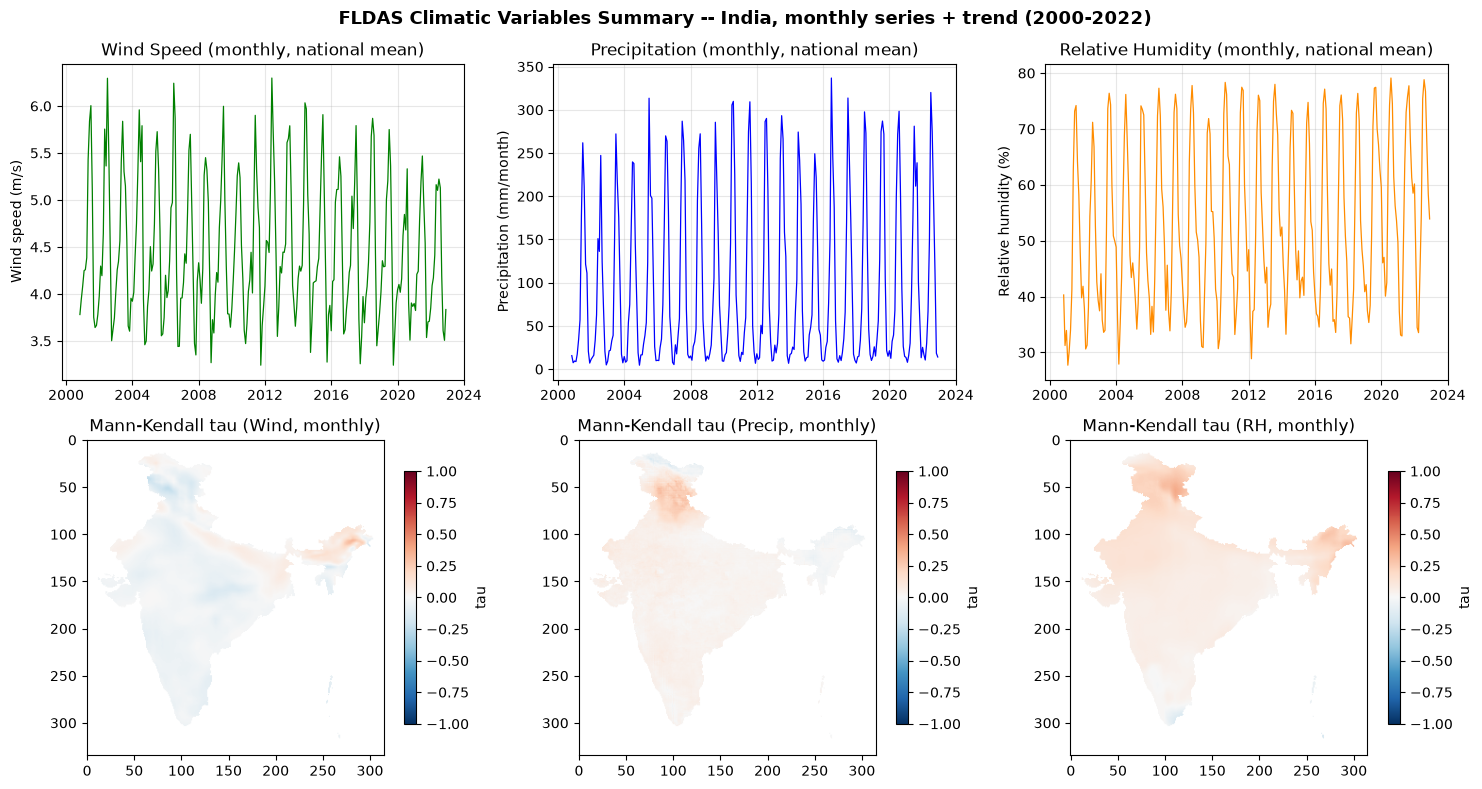

   Saved: D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\FLDAS_Summary_Analysis_Additional.png


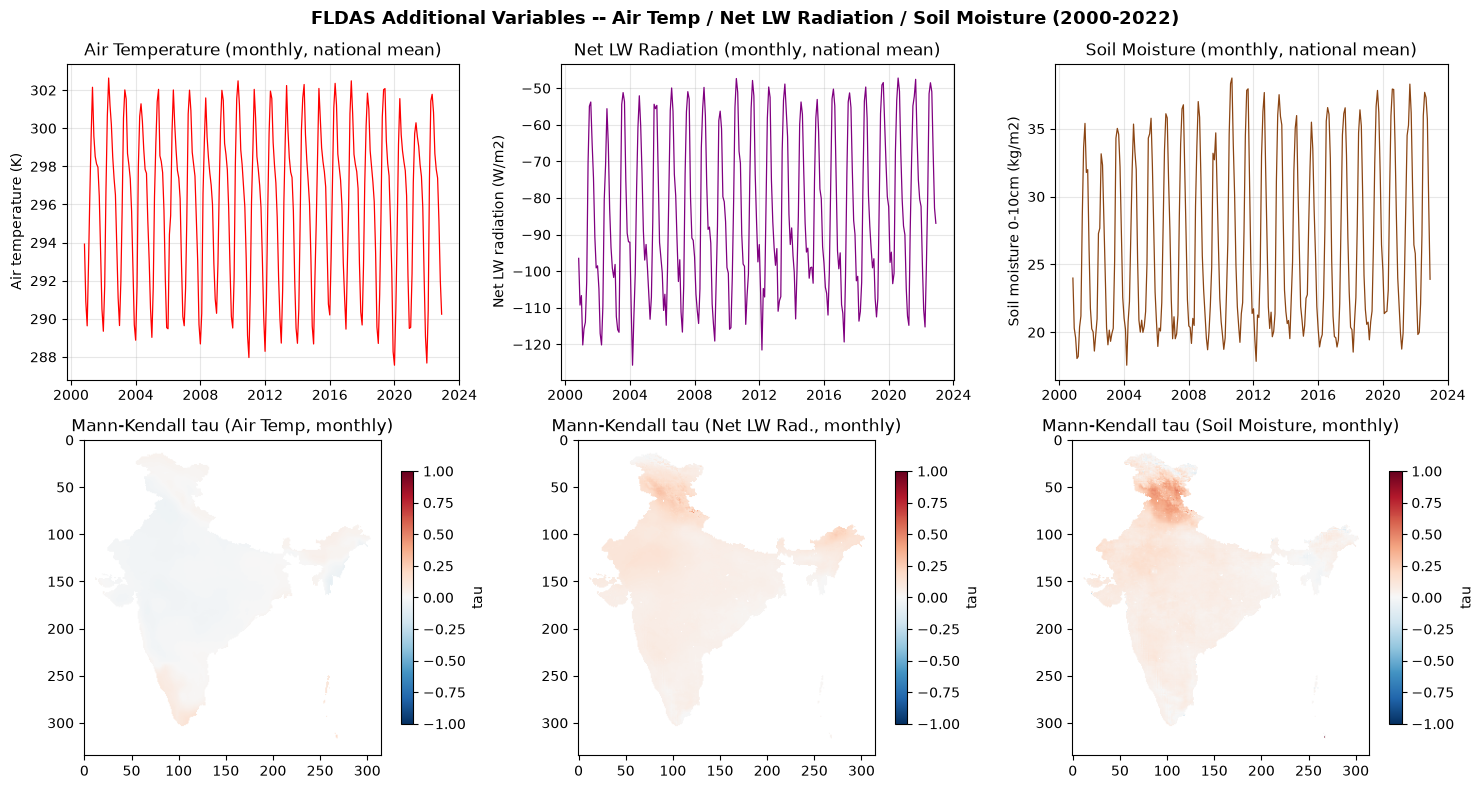

   Saved: D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\FLDAS_Fire_Coincidence.png


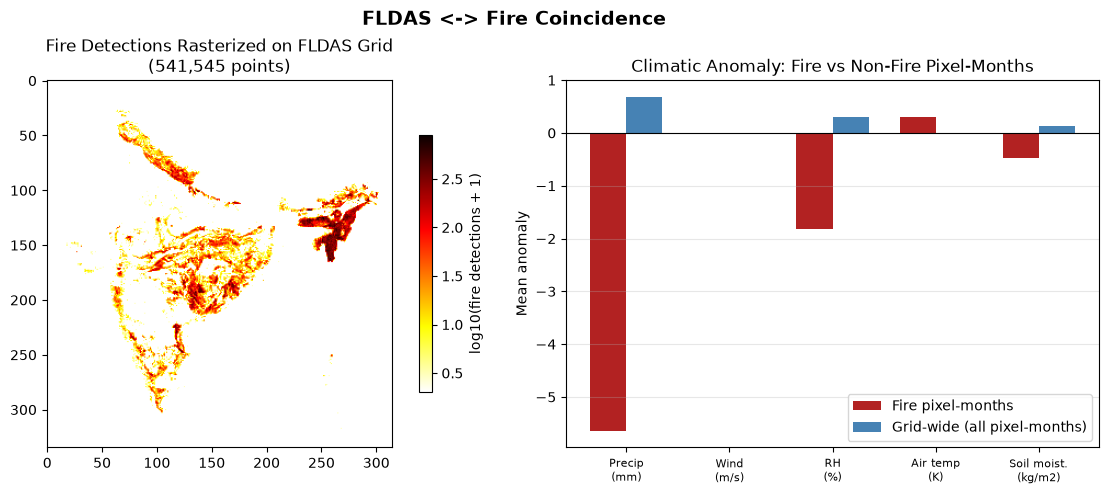

Visualizations complete


In [10]:
if len(df_study) > 0:
    print("Generating summary plots...")

    monthly_dates = df_study["date"].values

    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle("FLDAS Climatic Variables Summary -- India, monthly series + trend (2000-2022)",
                 fontsize=13, fontweight="bold")

    ax = axes[0, 0]
    ax.plot(monthly_dates, national_wind_ts, "g-", linewidth=0.9)
    ax.set_ylabel("Wind speed (m/s)"); ax.set_title("Wind Speed (monthly, national mean)")
    ax.grid(True, alpha=0.3)

    ax = axes[0, 1]
    ax.plot(monthly_dates, national_precip_ts, "b-", linewidth=0.9)
    ax.set_ylabel("Precipitation (mm/month)"); ax.set_title("Precipitation (monthly, national mean)")
    ax.grid(True, alpha=0.3)

    ax = axes[0, 2]
    ax.plot(monthly_dates, national_rh_ts, "darkorange", linewidth=0.9)
    ax.set_ylabel("Relative humidity (%)"); ax.set_title("Relative Humidity (monthly, national mean)")
    ax.grid(True, alpha=0.3)

    ax = axes[1, 0]
    im = ax.imshow(mk_wind["tau"], cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_title("Mann-Kendall tau (Wind, monthly)"); plt.colorbar(im, ax=ax, label="tau", shrink=0.8)

    ax = axes[1, 1]
    im = ax.imshow(mk_precip["tau"], cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_title("Mann-Kendall tau (Precip, monthly)"); plt.colorbar(im, ax=ax, label="tau", shrink=0.8)

    ax = axes[1, 2]
    im = ax.imshow(mk_rh["tau"], cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_title("Mann-Kendall tau (RH, monthly)"); plt.colorbar(im, ax=ax, label="tau", shrink=0.8)

    plt.tight_layout()
    outfile = os.path.join(OUTPUT_DIR, "FLDAS_Summary_Analysis.png")
    plt.savefig(outfile, dpi=150, bbox_inches="tight")
    print(f"   Saved: {outfile}")
    plt.show()

    # --- Second figure: the new Biswas-aligned variables (temp, LW radiation, soil moisture) ---
    fig1b, axes1b = plt.subplots(2, 3, figsize=(15, 8))
    fig1b.suptitle("FLDAS Additional Variables -- Air Temp / Net LW Radiation / Soil Moisture (2000-2022)",
                   fontsize=13, fontweight="bold")

    ax = axes1b[0, 0]
    ax.plot(monthly_dates, national_tair_ts, "r-", linewidth=0.9)
    ax.set_ylabel("Air temperature (K)"); ax.set_title("Air Temperature (monthly, national mean)")
    ax.grid(True, alpha=0.3)

    ax = axes1b[0, 1]
    ax.plot(monthly_dates, national_lwnet_ts, "purple", linewidth=0.9)
    ax.set_ylabel("Net LW radiation (W/m2)"); ax.set_title("Net LW Radiation (monthly, national mean)")
    ax.grid(True, alpha=0.3)

    ax = axes1b[0, 2]
    ax.plot(monthly_dates, national_soilm_surf_ts, "saddlebrown", linewidth=0.9)
    ax.set_ylabel("Soil moisture 0-10cm (kg/m2)"); ax.set_title("Soil Moisture (monthly, national mean)")
    ax.grid(True, alpha=0.3)

    ax = axes1b[1, 0]
    im = ax.imshow(mk_tair["tau"], cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_title("Mann-Kendall tau (Air Temp, monthly)"); plt.colorbar(im, ax=ax, label="tau", shrink=0.8)

    ax = axes1b[1, 1]
    im = ax.imshow(mk_lwnet["tau"], cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_title("Mann-Kendall tau (Net LW Rad., monthly)"); plt.colorbar(im, ax=ax, label="tau", shrink=0.8)

    ax = axes1b[1, 2]
    im = ax.imshow(mk_soilm["tau"], cmap="RdBu_r", vmin=-1, vmax=1)
    ax.set_title("Mann-Kendall tau (Soil Moisture, monthly)"); plt.colorbar(im, ax=ax, label="tau", shrink=0.8)

    plt.tight_layout()
    outfile1b = os.path.join(OUTPUT_DIR, "FLDAS_Summary_Analysis_Additional.png")
    plt.savefig(outfile1b, dpi=150, bbox_inches="tight")
    print(f"   Saved: {outfile1b}")
    plt.show()

    # --- Third figure: fire coincidence ---
    fig2, axes2 = plt.subplots(1, 2, figsize=(12, 5))
    fig2.suptitle("FLDAS <-> Fire Coincidence", fontsize=14, fontweight="bold")

    ax = axes2[0]
    im = ax.imshow(np.where(fire_count_map > 0, np.log10(fire_count_map + 1), np.nan), cmap="hot_r")
    ax.set_title(f"Fire Detections Rasterized on FLDAS Grid\n({len(df_fire):,} points)")
    plt.colorbar(im, ax=ax, label="log10(fire detections + 1)", shrink=0.7)

    ax = axes2[1]
    labels = ["Precip\n(mm)", "Wind\n(m/s)", "RH\n(%)", "Air temp\n(K)", "Soil moist.\n(kg/m2)"]
    fire_vals = [precip_anom_fire, wind_anom_fire, rh_anom_fire, tair_anom_fire, soilm_anom_fire]
    all_vals = [precip_anom_all, wind_anom_all, rh_anom_all, tair_anom_all, soilm_anom_all]
    x = np.arange(len(labels)); width = 0.35
    ax.bar(x - width/2, fire_vals, width, label="Fire pixel-months", color="firebrick")
    ax.bar(x + width/2, all_vals, width, label="Grid-wide (all pixel-months)", color="steelblue")
    ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8); ax.set_ylabel("Mean anomaly")
    ax.set_title("Climatic Anomaly: Fire vs Non-Fire Pixel-Months")
    ax.legend(); ax.grid(True, alpha=0.3, axis="y"); ax.axhline(0, color="black", linewidth=0.8)

    plt.tight_layout()
    outfile2 = os.path.join(OUTPUT_DIR, "FLDAS_Fire_Coincidence.png")
    plt.savefig(outfile2, dpi=150, bbox_inches="tight")
    print(f"   Saved: {outfile2}")
    plt.show()

    print("Visualizations complete")


## 💾 Step 10 — Export Results

Saves the monthly CSV (joinable on `(year, month)` against the NDVI/LST/fire monthly
tables), a trend summary, per-pixel GeoTIFFs on FLDAS's own India-cropped grid, and --
the key alignment deliverable -- the same monthly features reprojected onto the NDVI
pipeline's exact grid, ready to stack pixel-for-pixel with the other feature rasters
(same pattern as Step 3/Step 5).

In [11]:
if len(df_study) > 0:
    print("Exporting results...")

    # ---- 1. Monthly statistics CSV (join key: year, month) ----
    monthly_fire_totals = fire_monthly_count.reshape(n_months, -1).sum(axis=1)
    df_monthly_export = pd.DataFrame({
        "year": df_study["year"].values,
        "month": df_study["month"].values,
        "wind_mean": np.nanmean(monthly_wind, axis=(1, 2)),
        "precip_mm_mean": np.nanmean(monthly_precip, axis=(1, 2)),
        "precip_mmh_mean": np.nanmean(monthly_precip_mmh, axis=(1, 2)),
        "rh_mean": np.nanmean(monthly_rh, axis=(1, 2)),
        "tair_k_mean": np.nanmean(monthly_tair, axis=(1, 2)),
        "qair_kgkg_mean": np.nanmean(monthly_qair, axis=(1, 2)),
        "lwnet_wm2_mean": np.nanmean(monthly_lwnet, axis=(1, 2)),
        "soilm_surface_kgm2_mean": np.nanmean(monthly_soilm_surf, axis=(1, 2)),
        "soilm_total_kgm2_mean": np.nanmean(monthly_soilm_total, axis=(1, 2)),
        "wind_anom_mean": np.nanmean(anom_wind, axis=(1, 2)),
        "precip_anom_mean": np.nanmean(anom_precip, axis=(1, 2)),
        "rh_anom_mean": np.nanmean(anom_rh, axis=(1, 2)),
        "tair_anom_mean": np.nanmean(anom_tair, axis=(1, 2)),
        "lwnet_anom_mean": np.nanmean(anom_lwnet, axis=(1, 2)),
        "soilm_surface_anom_mean": np.nanmean(anom_soilm_surf, axis=(1, 2)),
        "fire_detections": monthly_fire_totals,
    })
    monthly_csv = os.path.join(OUTPUT_DIR, "FLDAS_monthly_statistics_NDVI_aligned.csv")
    df_monthly_export.to_csv(monthly_csv, index=False)
    print(f"   Saved: {monthly_csv}  <- join to the NDVI/LST/fire monthly tables on (year, month)")

    # ---- 2. Trend summary ----
    # tau_mean/tau_std/n_increasing_pixels/n_decreasing_pixels are unchanged from before --
    # p_mean and the n_significant_* columns are new diagnostic-only additions (p < 0.05,
    # two-sided normal approximation), matching Step 2 (NDVI)/Step 3 (LST)'s significance
    # reporting. They do not alter any existing tau/anomaly feature values.
    trend_metrics = {
        "Wind_monthly": mk_wind, "Precip_monthly": mk_precip, "RH_monthly": mk_rh,
        "AirTemp_monthly": mk_tair, "NetLWRadiation_monthly": mk_lwnet, "SoilMoisture_monthly": mk_soilm,
    }
    trend_summary = pd.DataFrame([
        {
            "metric": name,
            "tau_mean": float(np.nanmean(mk["tau"])),
            "tau_std": float(np.nanstd(mk["tau"])),
            "n_increasing_pixels": int((mk["trend_dir"] > 0).sum()),
            "n_decreasing_pixels": int((mk["trend_dir"] < 0).sum()),
            "p_mean": float(np.nanmean(mk["p"])),
            "n_significant_increasing_p05": int(np.sum((mk["p"] < 0.05) & (mk["tau"] > 0))),
            "n_significant_decreasing_p05": int(np.sum((mk["p"] < 0.05) & (mk["tau"] < 0))),
            "n_valid_pixels": int(np.sum(~np.isnan(mk["p"]))),
        }
        for name, mk in trend_metrics.items()
    ])
    trend_file = os.path.join(OUTPUT_DIR, "FLDAS_trend_summary.csv")
    trend_summary.to_csv(trend_file, index=False)
    print(f"   Saved: {trend_file}")

    # ---- 3. Per-pixel GeoTIFFs on the native FLDAS (India-cropped) grid ----
    def save_geotiff(array_2d, name, out_dir, transform, crs, shape):
        out_path = os.path.join(out_dir, f"{name}.tif")
        prof = {
            "driver": "GTiff", "height": shape[0], "width": shape[1], "count": 1,
            "dtype": "float32", "crs": crs, "transform": transform, "nodata": np.nan, "compress": "lzw",
        }
        with rasterio.open(out_path, "w", **prof) as dst:
            dst.write(array_2d.astype(np.float32), 1)
        return out_path

    native_layers = {
        "Wind_climatology_annualmean": np.nanmean(clim_wind, axis=0),
        "Precip_climatology_annualmean": np.nanmean(clim_precip, axis=0),
        "RH_climatology_annualmean": np.nanmean(clim_rh, axis=0),
        "AirTemp_climatology_annualmean": np.nanmean(clim_tair, axis=0),
        "NetLWRadiation_climatology_annualmean": np.nanmean(clim_lwnet, axis=0),
        "SoilMoisture_climatology_annualmean": np.nanmean(clim_soilm_surf, axis=0),
        "Wind_anomaly_mean": np.nanmean(anom_wind, axis=0),
        "Precip_anomaly_mean": np.nanmean(anom_precip, axis=0),
        "RH_anomaly_mean": np.nanmean(anom_rh, axis=0),
        "AirTemp_anomaly_mean": np.nanmean(anom_tair, axis=0),
        "NetLWRadiation_anomaly_mean": np.nanmean(anom_lwnet, axis=0),
        "SoilMoisture_anomaly_mean": np.nanmean(anom_soilm_surf, axis=0),
        "MannKendall_tau_Wind_monthly": mk_wind["tau"],
        "MannKendall_tau_Precip_monthly": mk_precip["tau"],
        "MannKendall_tau_RH_monthly": mk_rh["tau"],
        "MannKendall_tau_AirTemp_monthly": mk_tair["tau"],
        "MannKendall_tau_NetLWRadiation_monthly": mk_lwnet["tau"],
        "MannKendall_tau_SoilMoisture_monthly": mk_soilm["tau"],
        "Fire_count_map": fire_count_map.astype(np.float32),
    }
    for name, arr in native_layers.items():
        p = save_geotiff(arr, name, OUTPUT_DIR, transform_ref, crs_ref, (H, W))
        print(f"   Saved: {p}")

    # ---- 4. Reproject key monthly layers onto the NDVI pipeline's exact grid ----
    ndvi_ref_candidates = [f for f in sorted(Path(NDVI_RAW_DIR).glob("*_NDVI_*.tif")) if "reliability" not in f.name.lower()]

    if ndvi_ref_candidates:
        with rasterio.open(ndvi_ref_candidates[0]) as ndvi_ref:
            ndvi_transform = ndvi_ref.transform
            ndvi_crs = ndvi_ref.crs
            ndvi_shape = (ndvi_ref.height, ndvi_ref.width)

        def reproject_to_ndvi_grid(src_array):
            dst = np.full(ndvi_shape, np.nan, dtype=np.float32)
            reproject(
                source=np.ascontiguousarray(src_array.astype(np.float32)), destination=dst,
                src_transform=transform_ref, src_crs=crs_ref,
                dst_transform=ndvi_transform, dst_crs=ndvi_crs,
                src_nodata=np.nan, dst_nodata=np.nan,
                resampling=Resampling.bilinear,  # FLDAS (0.1deg) -> NDVI grid (0.01deg) is
                # upsampling, unlike Step 3/Step 4's finer->coarser averaging reprojections
            )
            return dst

        aligned_layers = {
            "Wind_anomaly_mean_on_NDVI_grid": native_layers["Wind_anomaly_mean"],
            "Precip_anomaly_mean_on_NDVI_grid": native_layers["Precip_anomaly_mean"],
            "RH_anomaly_mean_on_NDVI_grid": native_layers["RH_anomaly_mean"],
            "AirTemp_anomaly_mean_on_NDVI_grid": native_layers["AirTemp_anomaly_mean"],
            "NetLWRadiation_anomaly_mean_on_NDVI_grid": native_layers["NetLWRadiation_anomaly_mean"],
            "SoilMoisture_anomaly_mean_on_NDVI_grid": native_layers["SoilMoisture_anomaly_mean"],
            "MannKendall_tau_Wind_monthly_on_NDVI_grid": mk_wind["tau"],
            "MannKendall_tau_Precip_monthly_on_NDVI_grid": mk_precip["tau"],
            "MannKendall_tau_RH_monthly_on_NDVI_grid": mk_rh["tau"],
            "MannKendall_tau_AirTemp_monthly_on_NDVI_grid": mk_tair["tau"],
            "MannKendall_tau_NetLWRadiation_monthly_on_NDVI_grid": mk_lwnet["tau"],
            "MannKendall_tau_SoilMoisture_monthly_on_NDVI_grid": mk_soilm["tau"],
            "Fire_count_map_on_NDVI_grid": fire_count_map.astype(np.float32),
        }
        for name, arr in aligned_layers.items():
            resampled = reproject_to_ndvi_grid(arr)
            p = save_geotiff(resampled, name, NDVI_ALIGNED_DIR, ndvi_transform, ndvi_crs, ndvi_shape)
            print(f"   Saved (NDVI grid): {p}")

        print(f"\n   NDVI-aligned outputs written to: {NDVI_ALIGNED_DIR}")
        print(f"   Shape now matches the NDVI pipeline's grid: {ndvi_shape}")
    else:
        print("   WARNING: No NDVI reference GeoTIFF found in NDVI_RAW_DIR -- skipped NDVI-grid reprojection")

    print(f"\nResults exported to {OUTPUT_DIR}")


Exporting results...


   Saved: D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\FLDAS_monthly_statistics_NDVI_aligned.csv  <- join to the NDVI/LST/fire monthly tables on (year, month)
   Saved: D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\FLDAS_trend_summary.csv


   Saved: D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\Wind_climatology_annualmean.tif
   Saved: D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\Precip_climatology_annualmean.tif
   Saved: D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\RH_climatology_annualmean.tif
   Saved: D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\AirTemp_climatology_annualmean.tif
   Saved: D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\NetLWRadiation_climatology_annualmean.tif
   Saved: D:\FORE

   Saved: D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\RH_anomaly_mean.tif
   Saved: D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\AirTemp_anomaly_mean.tif
   Saved: D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\NetLWRadiation_anomaly_mean.tif
   Saved: D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\SoilMoisture_anomaly_mean.tif
   Saved: D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\MannKendall_tau_Wind_monthly.tif
   Saved: D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah

   Saved (NDVI grid): D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\NDVI_Aligned_GeoTIFFs\Wind_anomaly_mean_on_NDVI_grid.tif


...

   Saved (NDVI grid): D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\NDVI_Aligned_GeoTIFFs\MannKendall_tau_RH_monthly_on_NDVI_grid.tif


   Saved (NDVI grid): D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\NDVI_Aligned_GeoTIFFs\MannKendall_tau_AirTemp_monthly_on_NDVI_grid.tif


   Saved (NDVI grid): D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\NDVI_Aligned_GeoTIFFs\MannKendall_tau_NetLWRadiation_monthly_on_NDVI_grid.tif


   Saved (NDVI grid): D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\NDVI_Aligned_GeoTIFFs\MannKendall_tau_SoilMoisture_monthly_on_NDVI_grid.tif


   Saved (NDVI grid): D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\NDVI_Aligned_GeoTIFFs\Fire_count_map_on_NDVI_grid.tif

   NDVI-aligned outputs written to: D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\NDVI_Aligned_GeoTIFFs
   Shape now matches the NDVI pipeline's grid: (3641, 3504)

Results exported to D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs


## 🗺️ Step 11 — Land Cover, 22-Class ESA CCI Legend (Biswas-alignment)

Not FLDAS data -- this reuses the same ESA CCI/C3S LCCS archive Step 5 already reads for
its binary forest-fraction feature, but keeps the **full class breakdown** instead of
collapsing everything to forest/non-forest.

The raw LCCS legend has 38 codes (32 actually present over India: the base "tens" codes
10, 20, 30, ... 220, plus finer sub-variants like 61/62 splitting 60 into
closed/open canopy, or 11/12 splitting rainfed cropland into herbaceous/tree-shrub cover).
Collapsing each sub-variant to its parent (`base_code = (code // 10) * 10`) recovers
exactly the **22 base LCCS classes** -- this is the standard ESA CCI level-1 legend and the
most likely match for a paper citing "22 classes" against this archive.

For each of the 22 classes, this step builds a binary mask at the LULC archive's native
300m resolution, then area-averages it onto the NDVI grid (`Resampling.average` -- this
*is* a finer→coarser reprojection, same direction as Step 4's forest-fraction, unlike
FLDAS's upsampling above) to get a continuous 0-1 fractional-cover feature per class per
NDVI pixel -- 22 bands, one per class, all summing to ~1 per valid pixel.

Uses `LULC_YEAR = 2020` (Step 4's own "recent baseline" year) as a single representative
snapshot, matching how a static land-cover covariate is normally used in a susceptibility
model. The same function trivially extends to other years the same way Step 4 already
loops over baseline/recent/current for its forest-fraction feature, if a multi-year
breakdown is wanted later.

Loading ESA CCI/C3S land cover for 2020...


   Loaded: C3S-LC-L4-LCCS-Map-300m-P1Y-2020-v2.1.1.area-subset.37.5.98.6.67.5.nc  shape=(11340, 10980)


   21 of the 22 base classes present over this extent



Reclassifying to 22 base classes and computing per-pixel fractions on the NDVI grid (3641 x 3504)...


Reclassifying land-cover classes:   0%|          | 0/22 [00:00<?, ?it/s]

...

Reclassifying land-cover classes: 100%|██████████| 22/22 [00:39<00:00,  1.78s/it]

   22 class-fraction layers computed in 39.1 sec



   Top 5 classes by national mean fraction (India-masked, not the raster's full rectangular extent):
      LC22_10_cropland_rainfed                      35.00%
      LC22_20_cropland_irrigated                    20.94%
      LC22_60_tree_broadleaved_deciduous            8.02%
      LC22_130_grassland                            5.34%
      LC22_40_mosaic_natural_vegetation             4.72%



   Saved: D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\LandCover_22Class_Fractions_2020.tif  (22 bands, one per class, NDVI grid)


   Saved: D:\FOREST FIRE MAPPING(INDIA)\FLDAS Noah Land Surface Model L4 Global Monthly 0.1 x 0.1 degree (MERRA-2 and CHIRPS) (FLDAS_NOAH01_C_GL_M)\FLDAS_Outputs\LandCover_22Class_NationalMeanFraction.png


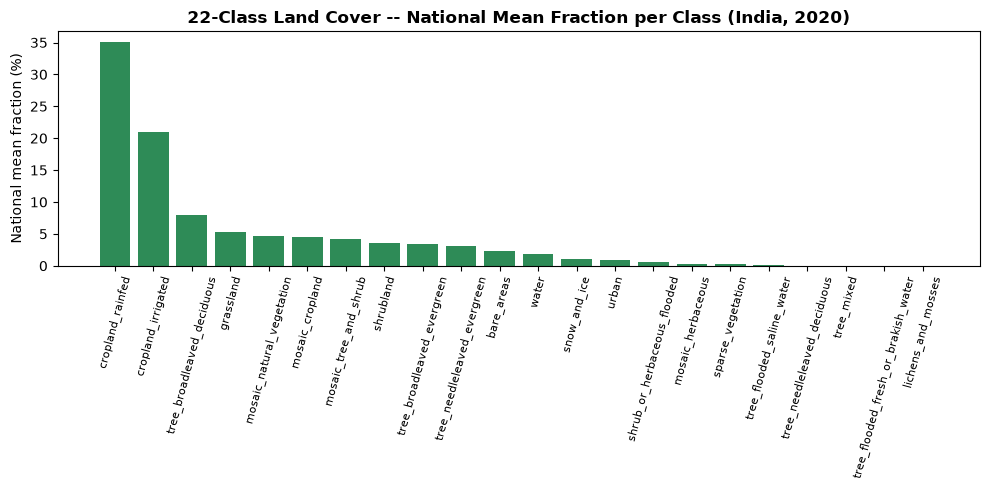


Land cover 22-class fractions ready


In [12]:
# The 22 base ESA CCI/C3S LCCS classes (sub-variants collapse to their parent code)
LCCS_22_CLASSES = {
    10: "cropland_rainfed", 20: "cropland_irrigated", 30: "mosaic_cropland",
    40: "mosaic_natural_vegetation", 50: "tree_broadleaved_evergreen",
    60: "tree_broadleaved_deciduous", 70: "tree_needleleaved_evergreen",
    80: "tree_needleleaved_deciduous", 90: "tree_mixed", 100: "mosaic_tree_and_shrub",
    110: "mosaic_herbaceous", 120: "shrubland", 130: "grassland",
    140: "lichens_and_mosses", 150: "sparse_vegetation",
    160: "tree_flooded_fresh_or_brakish_water", 170: "tree_flooded_saline_water",
    180: "shrub_or_herbaceous_flooded", 190: "urban", 200: "bare_areas",
    210: "water", 220: "snow_and_ice",
}


def find_lulc_file(year):
    candidates = sorted(Path(LULC_DIR).glob(f"*-{year}-*.nc"))
    if not candidates:
        raise FileNotFoundError(f"No LULC file found for year {year} in {LULC_DIR}")
    return candidates[0]


if os.path.isdir(LULC_DIR):
    print(f"Loading ESA CCI/C3S land cover for {LULC_YEAR}...")
    lulc_path = find_lulc_file(LULC_YEAR)
    with nc_lib.Dataset(lulc_path, 'r') as lds:
        lccs = np.asarray(lds.variables['lccs_class'][0, :, :])
        lulc_lat = np.asarray(lds.variables['lat'][:])
        lulc_lon = np.asarray(lds.variables['lon'][:])
    print(f"   Loaded: {lulc_path.name}  shape={lccs.shape}")

    base_codes = np.where(lccs == 0, 0, (lccs.astype(np.int32) // 10) * 10)
    present_codes = sorted(int(c) for c in np.unique(base_codes) if c != 0)
    print(f"   {len(present_codes)} of the 22 base classes present over this extent")

    lulc_res_lon = float(lulc_lon[1] - lulc_lon[0])
    lulc_res_lat = float(lulc_lat[0] - lulc_lat[1])
    lulc_west = float(lulc_lon[0] - lulc_res_lon / 2)
    lulc_north = float(lulc_lat[0] + lulc_res_lat / 2)
    lulc_src_transform = rasterio.transform.from_origin(lulc_west, lulc_north, lulc_res_lon, lulc_res_lat)

    ndvi_ref_candidates_lc = [f for f in sorted(Path(NDVI_RAW_DIR).glob("*_NDVI_*.tif")) if "reliability" not in f.name.lower()]
    with rasterio.open(ndvi_ref_candidates_lc[0]) as ndvi_ref:
        lc_ndvi_transform = ndvi_ref.transform
        lc_ndvi_crs = ndvi_ref.crs
        lc_ndvi_shape = (ndvi_ref.height, ndvi_ref.width)
        lc_ndvi_profile = ndvi_ref.profile.copy()

    # The NDVI raster's own extent is a rectangular bounding box that includes surrounding
    # sea (Arabian Sea / Bay of Bengal) beyond India's actual coastline -- rasterize the
    # real India polygon onto this grid so summary stats aren't diluted by ocean pixels.
    india_mask_lc = rasterize(
        [(india_geom, 1)], out_shape=lc_ndvi_shape, transform=lc_ndvi_transform, fill=0, dtype=np.uint8
    ).astype(bool)

    print(f"\nReclassifying to 22 base classes and computing per-pixel fractions on the NDVI grid "
          f"({lc_ndvi_shape[0]} x {lc_ndvi_shape[1]})...")
    t0 = time.time()
    class_fraction_layers = {}
    for code, name in tqdm(LCCS_22_CLASSES.items(), desc="Reclassifying land-cover classes"):
        mask = (base_codes == code).astype(np.float32)
        dst = np.full(lc_ndvi_shape, np.nan, dtype=np.float32)
        reproject(
            source=mask, destination=dst,
            src_transform=lulc_src_transform, src_crs="EPSG:4326",
            dst_transform=lc_ndvi_transform, dst_crs=lc_ndvi_crs,
            src_nodata=None, dst_nodata=np.nan,
            resampling=Resampling.average,  # 300m source -> ~1km NDVI grid is downsampling
        )
        class_fraction_layers[f"LC22_{code}_{name}"] = dst
    print(f"   {len(class_fraction_layers)} class-fraction layers computed in {time.time()-t0:.1f} sec")

    lc_names = list(class_fraction_layers.keys())
    # Restrict the summary stats to actual India-polygon pixels (india_mask_lc), not the
    # NDVI raster's full rectangular extent, which includes surrounding ocean.
    national_mean_frac = {n: float(np.nanmean(np.where(india_mask_lc, class_fraction_layers[n], np.nan))) for n in lc_names}
    top5 = sorted(national_mean_frac.items(), key=lambda kv: kv[1], reverse=True)[:5]
    print(f"\n   Top 5 classes by national mean fraction (India-masked, not the raster's full rectangular extent):")
    for n, v in top5:
        print(f"      {n:45s} {100*v:.2f}%")

    lc_stack_path = os.path.join(OUTPUT_DIR, f"LandCover_22Class_Fractions_{LULC_YEAR}.tif")
    lc_profile = lc_ndvi_profile.copy()
    lc_profile.update(count=len(lc_names), dtype='float32', nodata=np.nan, compress='lzw')
    with rasterio.open(lc_stack_path, 'w', **lc_profile) as dst:
        for i, name in enumerate(lc_names):
            dst.write(class_fraction_layers[name].astype(np.float32), i + 1)
            dst.set_band_description(i + 1, name)
    print(f"\n   Saved: {lc_stack_path}  ({len(lc_names)} bands, one per class, NDVI grid)")

    fig, ax = plt.subplots(figsize=(10, 5))
    sorted_frac = sorted(national_mean_frac.items(), key=lambda kv: kv[1], reverse=True)
    ax.bar([n.split('_', 2)[-1] for n, v in sorted_frac], [100 * v for n, v in sorted_frac], color='seagreen')
    ax.set_ylabel('National mean fraction (%)')
    ax.set_title('22-Class Land Cover -- National Mean Fraction per Class (India, ' + str(LULC_YEAR) + ')', fontweight='bold')
    ax.tick_params(axis='x', rotation=75, labelsize=8)
    plt.tight_layout()
    lc_outfile = os.path.join(OUTPUT_DIR, "LandCover_22Class_NationalMeanFraction.png")
    plt.savefig(lc_outfile, dpi=150, bbox_inches='tight')
    print(f"   Saved: {lc_outfile}")
    plt.show()

    print("\nLand cover 22-class fractions ready")
else:
    print(f"WARNING: LULC_DIR not found ({LULC_DIR}) -- skipped land-cover step")


## ✅ Pipeline Complete — Alignment Summary

**Outputs** (in `FLDAS_Outputs/`):

| File | Contents |
|---|---|
| `FLDAS_monthly_statistics_NDVI_aligned.csv` | Monthly wind/precip(mm/month+mm/h)/RH/air temp/specific humidity/net LW radiation/soil moisture means + anomalies + fire counts; join key `(year, month)` — matches `LST_monthly_statistics_NDVI_aligned.csv` and `Integrated_Monthly_TimeSeries.csv` |
| `FLDAS_trend_summary.csv` | Mann-Kendall τ summary (monthly resolution), 6 variables |
| Per-pixel GeoTIFFs (native FLDAS grid) | Climatology, anomaly, τ, fire count -- 6 climatic variables |
| `NDVI_Aligned_GeoTIFFs/` | Same monthly features reprojected (bilinear) onto the NDVI/LST/fire/LULC grid |
| `LandCover_22Class_Fractions_2020.tif` | 22-band GeoTIFF, one band per ESA CCI base class, fractional cover per NDVI pixel |
| `LandCover_22Class_NationalMeanFraction.png` | Which classes actually dominate India's land surface |

**Biswas et al. variable coverage after this notebook:** 10 of 11 variables are now
produced and aligned (NDVI + LST Day/Night from Steps 2-3; air temperature, wind speed,
specific humidity, precipitation, soil moisture, net LW radiation, fire points, and land
cover from this notebook). **Burned area is the one gap** -- no MODIS MCD64A1/FireCCI/GABAM
archive exists in this project; only fire hotspot points are available as a
fire-occurrence signal. Add it later by downloading MCD64A1 (monthly, 500m, LP DAAC) and
following this notebook's same crop -> mask -> reproject-to-NDVI-grid pattern.

**Wired into `Integrated_Analysis/Step6`** (done 2026-08-07): `FLDAS_Outputs/NDVI_Aligned_GeoTIFFs/*.tif` and `LandCover_22Class_Fractions_2020.tif`'s
22 bands are loaded the same way Step 5 loads `LST_Outputs/NDVI_Aligned_GeoTIFFs/*.tif`
(identical shape/transform/CRS, a straight `features[name] = read_grid_tif(fpath)`
append per band), and `FLDAS_monthly_statistics_NDVI_aligned.csv` is merged into
`Integrated_Monthly_TimeSeries.csv` on `(year, month)`.
